<a href="https://colab.research.google.com/github/JagdishMane/numpy-pytorch-tensorflow/blob/main/Predicting_Stock_Prices_Using_RNN_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3.1: Predicting Stock Prices Using RNN with LSTM


In [67]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

## 1. Data Preparation

In [68]:
df = pd.read_csv('./M3-AAPL.csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2019-05-28,44.730000,45.147499,44.477501,44.557499,43.002316,111792800
1,2019-05-29,44.105000,44.837502,44.000000,44.345001,42.797237,113924800
2,2019-05-30,44.487499,44.807499,44.167500,44.575001,43.019211,84873600
3,2019-05-31,44.057499,44.497501,43.747501,43.767502,42.239895,108174400
4,2019-06-03,43.900002,44.480000,42.567501,43.325001,41.812828,161584400


In [69]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,1259.000000,1259.000000,1259.000000,1259.000000,1259.000000,1.259000e+03
mean,133.653819,135.147178,132.262275,133.769406,132.106947,9.655618e+07
std,42.756938,43.062934,42.436917,42.756727,43.073091,5.190515e+07
min,43.860001,44.480000,42.567501,43.325001,41.812828,2.404830e+07
25%,112.485000,113.725003,110.000000,112.064999,109.641697,6.313855e+07
50%,143.800003,146.220001,142.539993,144.289993,142.543701,8.347440e+07
75%,169.345001,171.014999,168.154999,169.300003,168.303947,1.131188e+08
max,198.020004,199.619995,197.000000,198.110001,197.589523,4.265100e+08


In [70]:
### Check Missing values.
missing_values = df.isnull().sum()
display(missing_values)

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1259 non-null   object 
 1   Open       1259 non-null   float64
 2   High       1259 non-null   float64
 3   Low        1259 non-null   float64
 4   Close      1259 non-null   float64
 5   Adj Close  1259 non-null   float64
 6   Volume     1259 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 69.0+ KB


- No missing values.
- 1259 records.
- Date is object and Volume is in Integer

In [72]:
## Plot

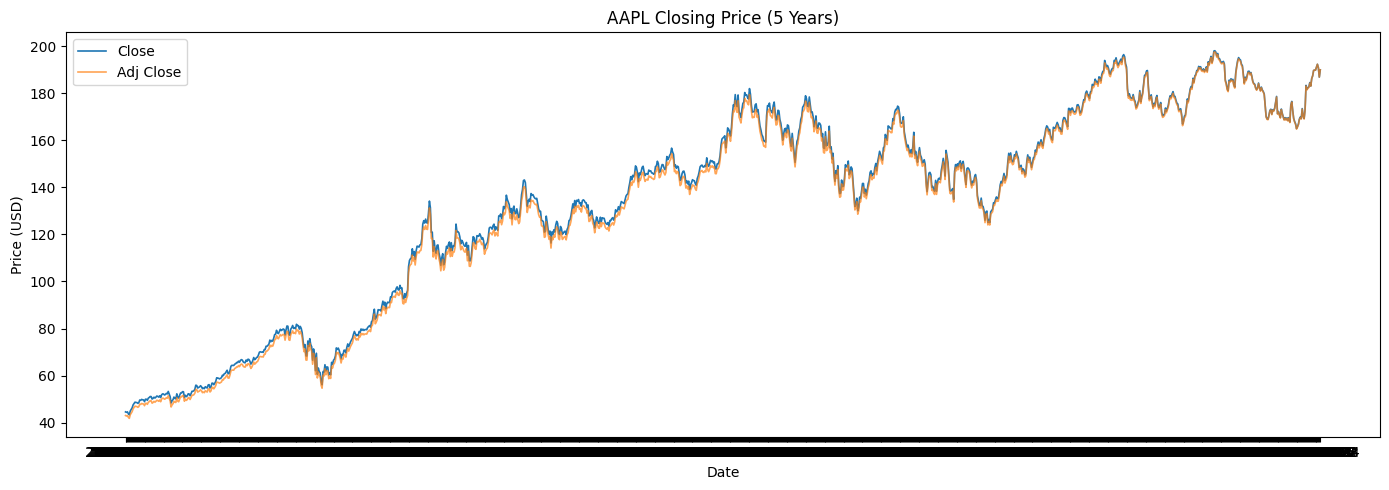

In [73]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df["Date"], df["Close"], label="Close", linewidth=1.2)
ax.plot(df["Date"], df["Adj Close"], label="Adj Close", linewidth=1.2, alpha=0.7)
ax.set_title("AAPL Closing Price (5 Years)")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()
plt.tight_layout()
plt.show()

## Feature Selection

We will predict the **Close** price using a sliding windows of past closing prices.

In [74]:
TARGET = "Close"       ### Target column for prediction
seq_length = 60          ### Past 60 days used to predict the next day Close price - Lookback window

FEATURES = ['Close', 'Open', 'High', 'Low', 'Volume'] # New features to be used
data_to_scale = df[FEATURES].values.astype("float32")

train_size = int(len(data_to_scale) * 0.8)
test_size = len(data_to_scale) - train_size
train_data_features = data_to_scale[:train_size,:]
test_data_features = data_to_scale[train_size:len(data_to_scale),:]
print(f"Train raw data size: {len(train_data_features)}")
print(f"Test raw data size: {len(test_data_features)}")

Train raw data size: 1007
Test raw data size: 252


In [75]:
### Normalize the data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))
train_data = scaler.fit_transform(train_data_features) # Use train_data_features
test_data = scaler.transform(test_data_features)     # Use test_data_features

In [77]:
### Create the training data
window_size = seq_length # Use the correctly named variable
X_train, y_train = [], []
target_feature_index = FEATURES.index(TARGET) # Get the index of the target feature ('Close')

for i in range(window_size, len(train_data)):
    X_train.append(train_data[i-window_size:i, :]) # Select all columns for input
    y_train.append(train_data[i, target_feature_index]) # Select only the target column for output
X_train, y_train = np.array(X_train), np.array(y_train)

In [78]:
### Create the testing data
window_size = seq_length # Use the correctly named variable
X_test, y_test = [], []
target_feature_index = FEATURES.index(TARGET) # Get the index of the target feature ('Close')

for i in range(window_size, len(test_data)):
    X_test.append(test_data[i-window_size:i, :]) # Select all columns for input
    y_test.append(test_data[i, target_feature_index]) # Select only the target column for output
X_test, y_test = np.array(X_test), np.array(y_test)

## RNN LSTM Model

In [79]:
import tensorflow as tf

num_features = len(FEATURES) # Get the number of features

### Build the LSTM Model
model = tf.keras.Sequential([
  tf.keras.layers.LSTM(units=64, return_sequences=True, input_shape=(window_size, num_features)), # Update input_shape
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.LSTM(units=32, return_sequences=False),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(32, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(1)
])

model.compile(optimizer="adam", loss="mse", metrics=["mae"])

### Train the Model
model.fit(X_train, y_train, epochs=300, batch_size=64)

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step - loss: 0.0851 - mae: 0.2258
Epoch 2/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.0277 - mae: 0.1267
Epoch 3/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.0202 - mae: 0.1080
Epoch 4/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.0184 - mae: 0.1023
Epoch 5/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 0.0178 - mae: 0.1005
Epoch 6/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 0.0166 - mae: 0.0950
Epoch 7/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - loss: 0.0138 - mae: 0.0899
Epoch 8/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 0.0137 - mae: 0.0884
Epoch 9/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - loss: 0.0131 - mae: 0.0877
Epoch 10/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: 0.0130 - mae: 0.0835
Epoch 11/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - loss: 0.0134 - mae: 0.0869
Epoch 12/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.0124 - mae: 0.0839
Epoch 13/300
15/15 ━━━━━━━━━━━━━━━━

## Prediction and Evaluation

In [80]:
import numpy as np
# Evaluate the model on the test data
mse = model.evaluate(X_test, y_test)
print(f"MSE: {mse}")

# Make prediction on the test data
predictions = model.predict(X_test)

# Denormalize the predictions and actual values.

# Create a dummy array for inverse_transform with the correct number of features
dummy_predictions = np.zeros((len(predictions), num_features))
# Place the actual predictions into the 'Close' price column (index 0, as TARGET is 'Close')
dummy_predictions[:, target_feature_index] = predictions.flatten()
# Inverse transform the dummy array
predictions = scaler.inverse_transform(dummy_predictions)[:, target_feature_index] # Extract only the 'Close' price

# Reshape y_test to match the original shape required by inverse_transform for a single feature
dummy_y_test = np.zeros((len(y_test), num_features))
dummy_y_test[:, target_feature_index] = y_test.flatten()
y_test = scaler.inverse_transform(dummy_y_test)[:, target_feature_index] # Extract only the 'Close' price

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 5.5115e-04 - mae: 0.0192
MSE: [0.0005511539638973773, 0.019226718693971634]
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step


## PLOT

## Model Evaluation and Visualization

In [81]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print(f"RMSE: {rmse}")

# Calculate MAE
mae = mean_absolute_error(y_test, predictions)
print(f"MAE: {mae}")

# Calculate MAPE (Mean Absolute Percentage Error)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape = mean_absolute_percentage_error(y_test, predictions)
print(f"MAPE: {mape:.2f}%")

RMSE: 3.255861650835982
MAE: 2.6664575558680386
MAPE: 1.46%


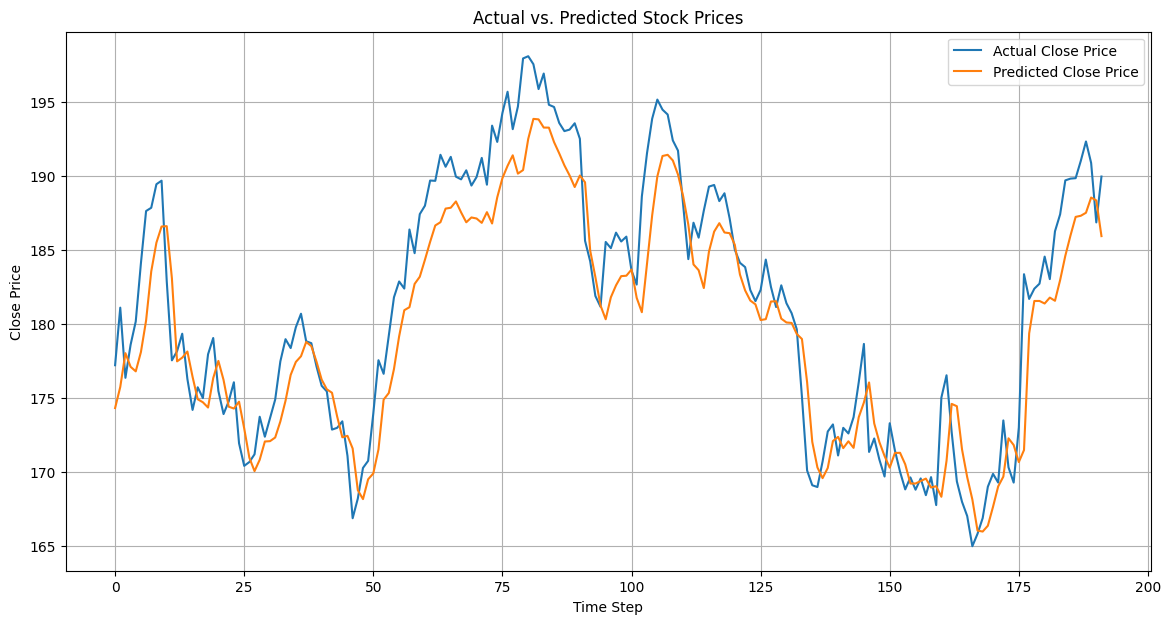

In [82]:
import matplotlib.pyplot as plt

# Visualize actual vs. predicted stock prices
plt.figure(figsize=(14, 7))
plt.plot(y_test, label='Actual Close Price')
plt.plot(predictions, label='Predicted Close Price')
plt.title('Actual vs. Predicted Stock Prices')
plt.xlabel('Time Step')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

**Interpretation**
- With RMSE = 3.26 . MAE 2.67 and MAPE 1.46%m shows the LSTM model performance is strong.
- The MAE of 2.67 means that, on average, the predicted Apple closing price differs from the actual closing price by approximately $2.67.
- The predicted values follow the overall direction of the actual closing prices closely. The model successfully captures:

  - upward and downward price trends;
  - major turning points;
  - medium-term price movements;
  - general volatility patterns.

However, the predicted curve is smoother than the actual curve. The model tends to:

- underestimate some price peaks;
react slightly late to sudden increases or decreases;
produce less extreme predictions than the actual values.

The LSTM model performs well in predicting Apple closing-price trends, with a low percentage error of 1.46%. It is effective at learning the general temporal pattern of the stock-price series, but it is less accurate during sudden market movements and high-volatility periods.